# DeepExtractor — Training Tutorial

This notebook trains a fresh `DeepExtractor_257` (U-Net 2D) model from scratch on a small synthetic
PyCBC noise dataset, plots the training and validation losses, and then tests the trained model
on held-out sine-Gaussian injections.

**What PyCBC noise means here:** the background noise is white Gaussian noise scaled to match
the variance of a whitened PyCBC noise realization. It is not coloured detector noise —
use `--bilby-noise` / `bilby_noise=True` for that.

**Pipeline overview:**
1. Generate synthetic time-domain data (noisy glitch + background pairs)
2. Convert to STFT spectrograms (magnitude + phase)
3. Train the U-Net on spectrogram pairs
4. Plot losses
5. Test on sine-Gaussian injections

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

from deepextractor.models.architectures import UNET2D
from deepextractor.generation.generate_timeseries import (
    generate_gaussian_noise, generate_synthetic_data, LENGTH, SAMPLE_RATE, T
)
from deepextractor.generation.glitch_functions import generate_sine_gaussian
from deepextractor.utils.signal import whitened_snr_scaling
from deepextractor.training.train_fn import train_fn
from deepextractor.utils.io import check_accuracy


## Configuration

In [2]:
# Device — uses MPS on Apple Silicon, CUDA on Linux/Windows GPU, otherwise CPU
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print(f"Using device: {DEVICE}")

# Dataset size — keep small for a quick demo; increase for real training
N_TRAIN = 1000
N_VAL   = 200

# Training
BATCH_SIZE              = 32
EPOCHS                  = 50    # maximum epochs; early stopping may stop sooner
LR                      = 1e-4
LR_PATIENCE             = 4     # epochs without improvement before LR is reduced
LR_FACTOR               = 0.1   # factor to reduce LR by
EARLY_STOPPING_PATIENCE = 9     # epochs without improvement before training stops

# STFT parameters
# Original DeepExtractor (arXiv:2501.18423): N_FFT=512, WIN_LENGTH=64, HOP_LENGTH=32
# → produces (257, 257) spectrograms, richer time-frequency representation
#   but significantly slower to train.
# Tutorial default: smaller spectrograms for faster training, but still gives decent performance (please see 129x129 model in the paper).
N_FFT      = 256
WIN_LENGTH = N_FFT // 2
HOP_LENGTH = WIN_LENGTH // 2


Using device: mps


## Step 1 — Generate synthetic time-domain data

Each training sample is a pair:
- **Input** `glitch`: background noise with 1–30 synthetic signal injections (chirps, sine-Gaussians, etc.)
- **Target** `background`: the same noise without any injections

The model learns to map glitchy strain → clean background.

In [3]:
mean, std_dev = 0, np.sqrt(SAMPLE_RATE)

print("Generating training noise...")
train_noise = generate_gaussian_noise(mean, std_dev, N_TRAIN, (LENGTH,), bilby_noise=False)
print("Generating validation noise...")
val_noise   = generate_gaussian_noise(mean, std_dev, N_VAL,   (LENGTH,), bilby_noise=False)

print("Generating training pairs...")
glitch_train, bg_train = generate_synthetic_data(train_noise, bilby_noise=False, phase="train")
print("Generating validation pairs...")
glitch_val,   bg_val   = generate_synthetic_data(val_noise,   bilby_noise=False, phase="val")

print(f"\nTrain: {glitch_train.shape}  |  Val: {glitch_val.shape}")

Generating training noise...
Generating pycbc noise...
Generating validation noise...
Generating pycbc noise...
Generating training pairs...


Generating Synthetic Train Data: 100%|██████████| 1000/1000 [00:02<00:00, 453.94it/s]


Generating validation pairs...


Generating Synthetic Val Data: 100%|██████████| 200/200 [00:00<00:00, 374.51it/s]


Train: (1000, 8192)  |  Val: (200, 8192)


## Step 2 — Scale and convert to spectrograms

In [4]:
scaler = StandardScaler()
glitch_train_scaled = scaler.fit_transform(glitch_train.reshape(-1, 1)).reshape(glitch_train.shape)
bg_train_scaled     = scaler.transform(bg_train.reshape(-1, 1)).reshape(bg_train.shape)
glitch_val_scaled   = scaler.transform(glitch_val.reshape(-1, 1)).reshape(glitch_val.shape)
bg_val_scaled       = scaler.transform(bg_val.reshape(-1, 1)).reshape(bg_val.shape)

# Uncomment to save the scaler for use outside this notebook
# import pickle, os
# os.makedirs('/tmp/de_training_tutorial', exist_ok=True)
# with open('/tmp/de_training_tutorial/scaler.pkl', 'wb') as f:
#     pickle.dump(scaler, f)

# Convert to STFT spectrograms (in-memory)
window = torch.hann_window(WIN_LENGTH)

def to_mag_phase(arrays):
    """Convert a numpy array (N, time) to a (N, 2, F, T) mag/phase tensor."""
    t = torch.tensor(arrays, dtype=torch.float32)
    stft = torch.stft(t, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH,
                      window=window, return_complex=True)
    mag   = torch.abs(stft)
    phase = torch.angle(stft)
    return torch.stack([mag, phase], dim=1)  # (N, 2, F, T)

glitch_train_spec = to_mag_phase(glitch_train_scaled)
bg_train_spec     = to_mag_phase(bg_train_scaled)
glitch_val_spec   = to_mag_phase(glitch_val_scaled)
bg_val_spec       = to_mag_phase(bg_val_scaled)

print(f"Spectrogram shape: {glitch_train_spec.shape}  — (N, 2, freq_bins, time_bins)")

# Uncomment to save spectrograms to disk (useful for large datasets or re-use)
# os.makedirs('/tmp/de_training_tutorial/spectrogram_domain', exist_ok=True)
# for name, arr in [
#     ('glitch_train_scaled_mag_phase',     glitch_train_spec.numpy()),
#     ('background_train_scaled_mag_phase', bg_train_spec.numpy()),
#     ('glitch_val_scaled_mag_phase',       glitch_val_spec.numpy()),
#     ('background_val_scaled_mag_phase',   bg_val_spec.numpy()),
# ]:
#     np.save(f'/tmp/de_training_tutorial/spectrogram_domain/{name}', arr)


Spectrogram shape: torch.Size([1000, 2, 129, 129])  — (N, 2, freq_bins, time_bins)


## Step 3 — Build model and data loaders

In [5]:
from torch.utils.data import TensorDataset, DataLoader

# Model architecture
# Original DeepExtractor (arXiv:2501.18423): features=[64, 128, 256, 512] — ~31M parameters.
# Use those to train a model equivalent to the published DeepExtractor.
# Tutorial default: one fewer layer and half the filters for faster training.
model = UNET2D(in_channels=2, out_channels=2, features=[32, 64, 128, 256]).to(DEVICE)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

train_ds = TensorDataset(glitch_train_spec, bg_train_spec)
val_ds   = TensorDataset(glitch_val_spec,   bg_val_spec)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")
print(f"Spectrogram shape: {glitch_train_spec.shape}  — (N, 2, freq_bins, time_bins)")


Model parameters: 7,762,786
Train batches: 32  |  Val batches: 7
Spectrogram shape: torch.Size([1000, 2, 129, 129])  — (N, 2, freq_bins, time_bins)


## Step 4 — Train

In [6]:
loss_fn   = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=LR_FACTOR, patience=LR_PATIENCE)
amp_scaler = torch.amp.GradScaler("cuda") if DEVICE == "cuda" else torch.amp.GradScaler("cpu")

train_losses, val_losses = [], []
best_val_loss           = float("inf")
early_stopping_counter  = 0

for epoch in range(EPOCHS):
    train_loss, _, _ = train_fn(
        train_loader, model, "DeepExtractor_257", optimizer, loss_fn, amp_scaler, DEVICE
    )
    val_loss, _, _ = check_accuracy(val_loader, model, "DeepExtractor_257", device=DEVICE)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:>3}/{EPOCHS}  train={train_loss:.5f}  val={val_loss:.5f}  lr={current_lr:.1e}")

    if val_loss < best_val_loss:
        best_val_loss          = val_loss
        early_stopping_counter = 0
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= EARLY_STOPPING_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {EARLY_STOPPING_PATIENCE} epochs).")
            break

print("\nTraining complete.")


Training on batch: 100%|██████████| 32/32 [00:11<00:00,  2.83it/s, loss=1.95]


Validation Loss: 2.218210
Epoch   1/50  train=2.32153  val=2.21821  lr=1.0e-04


Training on batch: 100%|██████████| 32/32 [00:10<00:00,  3.05it/s, loss=1.54]


Validation Loss: 1.511046
Epoch   2/50  train=1.68615  val=1.51105  lr=1.0e-04


Training on batch: 100%|██████████| 32/32 [00:10<00:00,  3.02it/s, loss=1.22]


...

Validation Loss: 0.521620
Epoch  48/50  train=0.48950  val=0.52162  lr=1.0e-04


Training on batch: 100%|██████████| 32/32 [00:13<00:00,  2.32it/s, loss=0.521]


Validation Loss: 0.520201
Epoch  49/50  train=0.48736  val=0.52020  lr=1.0e-04


Training on batch: 100%|██████████| 32/32 [00:13<00:00,  2.33it/s, loss=0.614]


Validation Loss: 0.521240
Epoch  50/50  train=0.48693  val=0.52124  lr=1.0e-04

Training complete.


## Step 5 — Plot losses

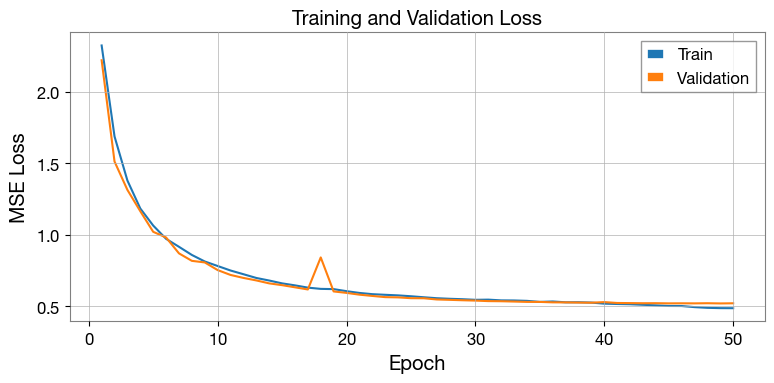

In [7]:
epochs_ran = range(1, len(train_losses) + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs_ran, train_losses, label="Train",      color="C0")
ax.plot(epochs_ran, val_losses,   label="Validation", color="C1")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Training and Validation Loss")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


## Step 6 — Test on sine-Gaussian injections

We generate fresh test examples — PyCBC (numpy) noise with a sine-Gaussian injected at a range of SNRs —
and run them through the trained model.
The model was never trained on these specific examples.

In [8]:
def reconstruct(noisy_signal, model, scaler, device, n_fft, hop_length, win_length):
    """Scale → STFT → U-Net → iSTFT → unscale → subtract background."""
    # Scale
    scaled = scaler.transform(noisy_signal.reshape(-1, 1)).reshape(noisy_signal.shape)

    # STFT
    window = torch.hann_window(win_length)
    t = torch.tensor(scaled, dtype=torch.float32).unsqueeze(0)  # (1, time)
    stft = torch.stft(t, n_fft=n_fft, hop_length=hop_length, win_length=win_length,
                      window=window, return_complex=True)
    mag   = torch.abs(stft)
    phase = torch.angle(stft)
    spec  = torch.stack([mag, phase], dim=1)  # (1, 2, F, T)

    # U-Net inference
    model.eval()
    with torch.no_grad():
        bg_spec = model(spec.to(device)).cpu()  # predicted background spectrogram

    # iSTFT
    bg_mag   = bg_spec[:, 0, :, :]
    bg_phase = bg_spec[:, 1, :, :]
    bg_complex = bg_mag * torch.exp(1j * bg_phase)
    bg_td = torch.istft(bg_complex, n_fft=n_fft, hop_length=hop_length,
                        win_length=win_length, window=window,
                        length=noisy_signal.shape[-1])

    # Unscale and subtract background to recover signal
    bg_unscaled = scaler.inverse_transform(bg_td.numpy().reshape(-1, 1)).reshape(-1)
    noisy_unscaled = noisy_signal.copy()
    reconstruction = noisy_unscaled - bg_unscaled
    return reconstruction

Generating pycbc noise...
Generating pycbc noise...
Generating pycbc noise...


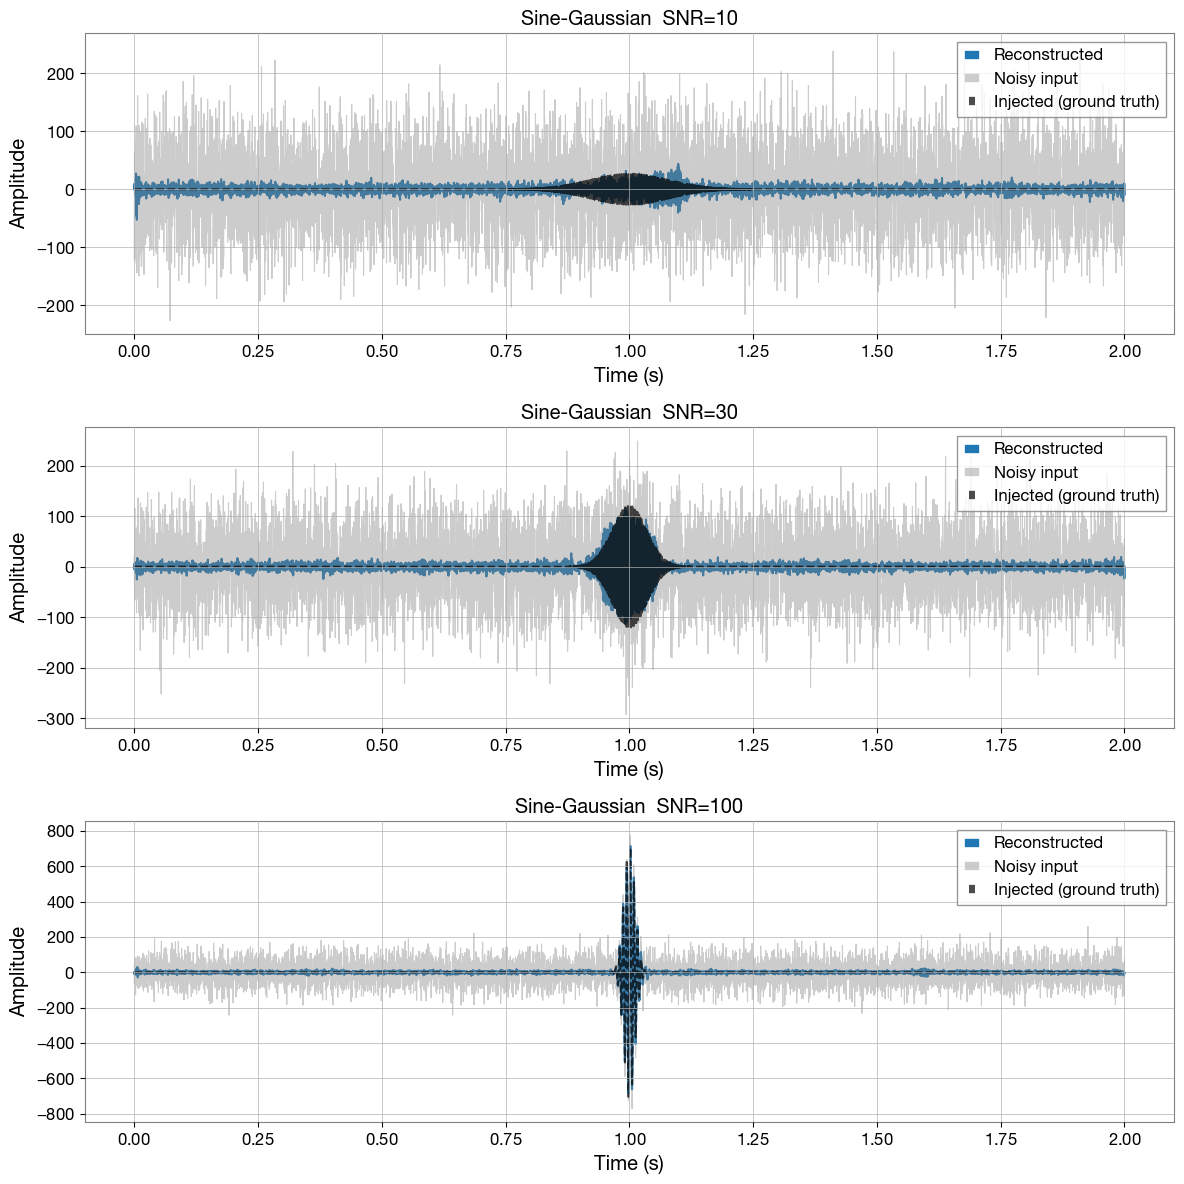

In [10]:
T_INJ = T / 2
SNR_VALUES = [10, 30, 100]

def overlap(a, b):
    """Normalised time-domain overlap (match) between two real signals.
    Equivalent to the PyCBC match on whitened data (flat PSD)."""
    return np.dot(a, b) / np.sqrt(np.dot(a, a) * np.dot(b, b))

fig, axes = plt.subplots(len(SNR_VALUES), 1, figsize=(12, 4 * len(SNR_VALUES)))
t_axis = np.linspace(0, T, LENGTH)

for ax, snr in zip(axes, SNR_VALUES):
    noise = generate_gaussian_noise(mean, std_dev, 1, (LENGTH,), bilby_noise=False)[0]

    _, wavelet = generate_sine_gaussian(duration=0.5, freq_max=1024)
    wavelet = wavelet - np.mean(wavelet)
    wavelet = whitened_snr_scaling(wavelet, snr=snr)

    len_glitch = len(wavelet)
    id_start   = int(T_INJ * SAMPLE_RATE) - len_glitch // 2
    noisy      = noise.copy()
    noisy[id_start : id_start + len_glitch] += wavelet

    injected = np.zeros(LENGTH)
    injected[id_start : id_start + len_glitch] = wavelet

    reconstructed = reconstruct(noisy, model, scaler, DEVICE, N_FFT, HOP_LENGTH, WIN_LENGTH)

    match    = overlap(injected, reconstructed)
    mismatch = 1.0 - match

    ax.plot(t_axis, injected,      color="black", lw=1.5, linestyle="--", label="Injected (ground truth)")
    ax.plot(t_axis, reconstructed, color="C0",    lw=1.5, label="Reconstructed")
    ax.plot(t_axis, noisy,         color="gray",  lw=0.8, alpha=0.4, label="Noisy input")
    ax.set_title(
        f"Sine-Gaussian  SNR={snr}  |  "
        f"Match $= {match:.3f}$,  $\\mathcal{{M}} = {mismatch:.3f}$"
    )
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.legend(loc="upper right")
    ax.grid(True)

plt.tight_layout()
plt.show()
